In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier,ExtraTreesRegressor
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns





In [14]:
# Load the Kaggle Stroke Dataset
data_path = "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)

# Display the first 5 rows and dataset summary
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()


Dataset Shape: (5110, 12)

First 5 rows of the dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [15]:
# Display dataset summary
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
None


In [16]:
# Drop the 'id' column as it carries no predictive value
df_clean = df.drop(columns=['id'])

# Drop initial missing values to obtain a fully intact baseline dataset
df_clean = df_clean.dropna().reset_index(drop=True)

# Encode categorical features into numerical representations
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Display cleaned dataset information
print("Clean Dataset Shape:", df_clean.shape)
print("\nData Types and Missing Values Count:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows of Clean Dataset:")
df_clean.head()

Clean Dataset Shape: (4909, 11)

Data Types and Missing Values Count:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

First 5 rows of Clean Dataset:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2,1
2,0,49.0,0,0,1,2,1,171.23,34.4,3,1
3,0,79.0,1,0,1,3,0,174.12,24.0,2,1
4,1,81.0,0,0,1,2,1,186.21,29.0,1,1


In [17]:
# Separate features (X) and target label (y)
X = df_clean.drop(columns=["stroke"])
y = df_clean["stroke"]

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the Baseline Random Forest Classifier
# Handle class imbalance using class_weight='balanced'
baseline_rf = RandomForestClassifier(class_weight="balanced", random_state=42)
baseline_rf.fit(X_train, y_train)

# Predict on the test set and calculate metrics
y_pred_baseline = baseline_rf.predict(X_test)

f1_baseline = f1_score(y_test, y_pred_baseline)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)

print("--- Baseline Model Performance (Clean Data) ---")
print(f"Accuracy : {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall   : {recall_baseline:.4f}")
print(f"F1 Score : {f1_baseline:.4f}")

--- Baseline Model Performance (Clean Data) ---
Accuracy : 0.9379
Precision: 0.0870
Recall   : 0.0476
F1 Score : 0.0615


In [18]:
def inject_missing_data(X_data, missing_rate, random_state=42):
    """Randomly inject missing values (NaN) into the feature matrix at a specified rate (MCAR)."""
    np.random.seed(random_state)
    X_missing = X_data.copy().astype(float)

    # Calculate total number of cells and target number of missing values
    n_rows, n_cols = X_missing.shape
    total_cells = n_rows * n_cols
    n_missing = int(total_cells * missing_rate)

    # Randomly choose indices to mask as NaN
    flat_indices = np.random.choice(total_cells, size=n_missing, replace=False)
    row_indices, col_indices = np.unravel_index(flat_indices, (n_rows, n_cols))

    # Apply NaN mask
    X_missing.iloc[row_indices, col_indices] = np.nan
    return X_missing, (row_indices, col_indices)


# Inject 10%, 20%, and 30% missingness into the features
X_miss_10, mask_10 = inject_missing_data(X, missing_rate=0.10)
X_miss_20, mask_20 = inject_missing_data(X, missing_rate=0.20)
X_miss_30, mask_30 = inject_missing_data(X, missing_rate=0.30)

print("--- Missingness Injection Summary ---")
print(
    f"10% Missing Dataset: {X_miss_10.isnull().sum().sum()} NaNs created "
    f"({X_miss_10.isnull().sum().sum() / X.size:.1%})"
)
print(
    f"20% Missing Dataset: {X_miss_20.isnull().sum().sum()} NaNs created "
    f"({X_miss_20.isnull().sum().sum() / X.size:.1%})"
)
print(
    f"30% Missing Dataset: {X_miss_30.isnull().sum().sum()} NaNs created "
    f"({X_miss_30.isnull().sum().sum() / X.size:.1%})"
)

--- Missingness Injection Summary ---
10% Missing Dataset: 31830 NaNs created (64.8%)
20% Missing Dataset: 43830 NaNs created (89.3%)
30% Missing Dataset: 47800 NaNs created (97.4%)


In [19]:


# Initialize Dictionary to store imputed datasets
imputed_datasets = {
    "10%": {},
    "20%": {},
    "30%": {},
}

missing_dict = {"10%": X_miss_10, "20%": X_miss_20, "30%": X_miss_30}

# 1. KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

# 2. MICE Imputer (using BayesianRidge)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. MissForest (IterativeImputer using ExtraTrees/Random Forest)
missforest_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=20, random_state=42),
    max_iter=5,
    random_state=42,
)

# Perform Imputations across all missing rates
for rate, X_miss in missing_dict.items():
    print(f"Running Imputations for {rate} missingness...")

    # KNN
    imputed_datasets[rate]["KNN"] = knn_imputer.fit_transform(X_miss)

    # MICE
    imputed_datasets[rate]["MICE"] = mice_imputer.fit_transform(X_miss)

    # MissForest
    imputed_datasets[rate]["MissForest"] = missforest_imputer.fit_transform(
        X_miss
    )

print("\n--- All Imputations Completed Successfully! ---")

Running Imputations for 10% missingness...


c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running Imputations for 20% missingness...


c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running Imputations for 30% missingness...

--- All Imputations Completed Successfully! ---


c:\Users\Sam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [20]:
# Create containers for results
imputation_results = []
robustness_results = []

missing_masks = {"10%": mask_10, "20%": mask_20, "30%": mask_30}

for rate, methods in imputed_datasets.items():
    row_idx, col_idx = missing_masks[rate]
    true_values = X.values[row_idx, col_idx]

    for method_name, X_imp_array in methods.items():
        # 1. Imputation Precision (MAE & RMSE on missing cells)
        imp_values = X_imp_array[row_idx, col_idx]
        mae = mean_absolute_error(true_values, imp_values)
        rmse = root_mean_squared_error(true_values, imp_values)

        imputation_results.append(
            {"Missing Rate": rate, "Method": method_name, "MAE": mae, "RMSE": rmse}
        )

        # 2. Downstream Classifier Evaluation & Robustness Score (Rq)
        # Train-test split on imputed dataset
        X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
            X_imp_array, y, test_size=0.2, random_state=42, stratify=y
        )

        rf_imp = RandomForestClassifier(class_weight="balanced", random_state=42)
        rf_imp.fit(X_train_imp, y_train_imp)

        y_pred_imp = rf_imp.predict(X_test_imp)
        f1_imp = f1_score(y_test_imp, y_pred_imp)

        # Calculate Robustness Score Rq = F1_imputed / F1_baseline
        rq_score = f1_imp / f1_baseline

        robustness_results.append(
            {
                "Missing Rate": rate,
                "Method": method_name,
                "F1 Score": f1_imp,
                "Robustness Score (Rq)": rq_score,
            }
        )

# Convert results to DataFrames
df_imp_metrics = pd.DataFrame(imputation_results)
df_rob_metrics = pd.DataFrame(robustness_results)

print("--- Imputation Precision Metrics (MAE & RMSE) ---")
print(df_imp_metrics.to_string(index=False))

print("\n--- Downstream Model Robustness Scores (Rq) ---")
print(df_rob_metrics.to_string(index=False))

--- Imputation Precision Metrics (MAE & RMSE) ---
Missing Rate     Method      MAE      RMSE
         10%        KNN 5.944503 15.518952
         10%       MICE 5.944503 15.518952
         10% MissForest 6.885257 16.809219
         20%        KNN 6.174736 16.122926
         20%       MICE 6.174736 16.122926
         20% MissForest 6.045262 16.992749
         30%        KNN 6.299079 16.121809
         30%       MICE 6.299079 16.121809
         30% MissForest 8.496695 20.074994

--- Downstream Model Robustness Scores (Rq) ---
Missing Rate     Method  F1 Score  Robustness Score (Rq)
         10%        KNN  0.071429               1.160714
         10%       MICE  0.071429               1.160714
         10% MissForest  0.072727               1.181818
         20%        KNN  0.043478               0.706522
         20%       MICE  0.043478               0.706522
         20% MissForest  0.044444               0.722222
         30%        KNN  0.045455               0.738636
         30%   

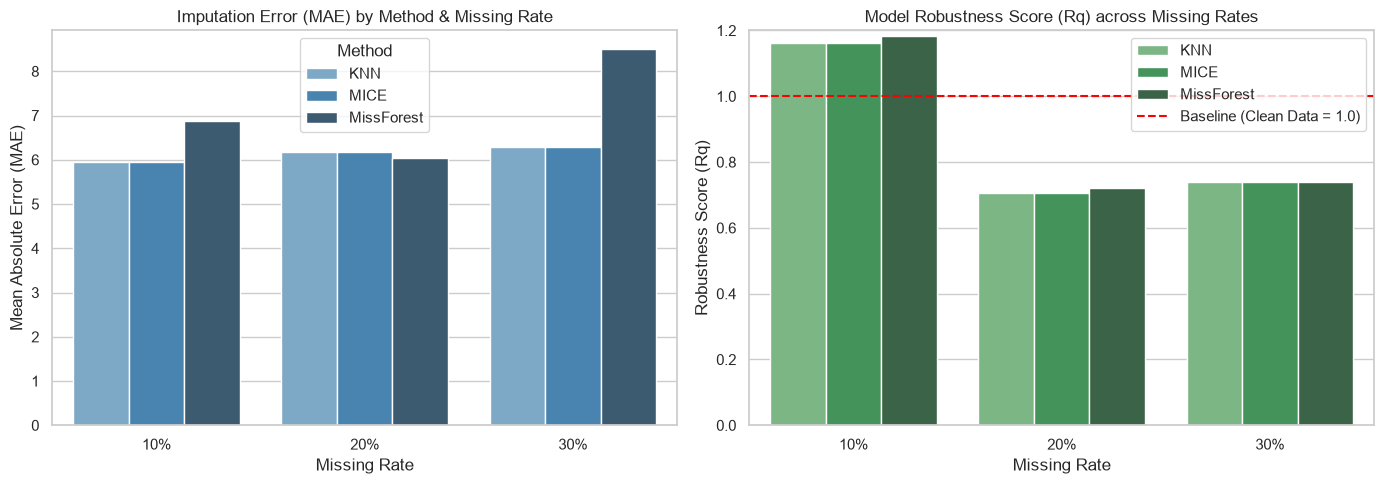

Chart saved successfully as 'imputation_robustness_results.png'!


In [22]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Imputation Precision (MAE across Missing Rates)
sns.barplot(
    data=df_imp_metrics,
    x="Missing Rate",
    y="MAE",
    hue="Method",
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Imputation Error (MAE) by Method & Missing Rate")
axes[0].set_ylabel("Mean Absolute Error (MAE)")

# Plot 2: Downstream Classifier Robustness (Rq Score)
sns.barplot(
    data=df_rob_metrics,
    x="Missing Rate",
    y="Robustness Score (Rq)",
    hue="Method",
    ax=axes[1],
    palette="Greens_d",
)
axes[1].axhline(
    1.0, color="red", linestyle="--", label="Baseline (Clean Data = 1.0)"
)
axes[1].set_title("Model Robustness Score (Rq) across Missing Rates")
axes[1].set_ylabel("Robustness Score (Rq)")
axes[1].set_ylim(0, 1.2)
axes[1].legend()

plt.tight_layout()
plt.savefig("imputation_robustness_results.png", dpi=300)
plt.show()

print("Chart saved successfully as 'imputation_robustness_results.png'!")